<a href="https://colab.research.google.com/github/springboardmentorLive/Reality_AI/blob/bhaskar/IPL_dataset_randomforest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns#plotting and visualizing
from sklearn import preprocessing
import keras #building & traing nural n/w
import tensorflow as tf # backend frameewok for ml/dl

In [ ]:
ipl = pd.read_csv('/content/ipl2020_synthetic.csv')
ipl.head()


,MatchID,Date,Team1,Team2,Venue,TossWinner,TossDecision,Team1_Runs,Team2_Runs,Winner,WinType,WinMargin
0,1000,2020-10-12,DC,SRH,Abu Dhabi,DC,bat,222,202,DC,runs,20
1,1001,2020-09-30,MI,SRH,Sharjah,SRH,bat,121,183,SRH,runs,62
2,1002,2020-11-04,RCB,KXIP,Abu Dhabi,KXIP,field,178,161,RCB,runs,17
3,1003,2020-10-27,DC,CSK,Sharjah,DC,bat,220,170,DC,runs,50
4,1004,2020-11-17,SRH,KXIP,Abu Dhabi,SRH,field,128,209,KXIP,runs,81


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
team_encoder = LabelEncoder()
teams = pd.concat([ipl['Team1'], ipl['Team2']])

team_encoder.fit(teams)

ipl["Team1_enc"] = team_encoder.transform(ipl["Team1"])
ipl["Team2_enc"] = team_encoder.transform(ipl["Team2"])
ipl["Winner_enc"] = team_encoder.transform(ipl["Winner"])


In [ ]:
ipl['TossWinner_enc'] = team_encoder.transform(ipl['TossWinner'])
ipl['TossDecision_bin'] = ipl['TossDecision'].apply(lambda x: 1 if x == "bat" else 0)

features = ["Team1_enc", "Team2_enc", "TossWinner_enc", "TossDecision_bin"]

X = ipl[features]
y1 = ipl["Team1_Runs"]
y2 = ipl["Team2_Runs"]

X_train, X_test, y1_train, y1_test = train_test_split(X, y1, test_size=0.2, random_state=42)
X_train2, X_test2, y2_train, y2_test = train_test_split(X, y2, test_size=0.2, random_state=42)

model_t1 = RandomForestRegressor(n_estimators=300, random_state=42)
model_t2 = RandomForestRegressor(n_estimators=300, random_state=42)

model_t1.fit(X_train, y1_train)
model_t2.fit(X_train2, y2_train)


RandomForestRegressor(n_estimators=300, random_state=42)

In [ ]:
pred1 = model_t1.predict(X_test)
pred2 = model_t2.predict(X_test2)

print("Team1 Score Prediction R2:", r2_score(y1_test, pred1))
print("Team2 Score Prediction R2:", r2_score(y2_test, pred2))


Team1 Score Prediction R2: -1.5188594606769668
Team2 Score Prediction R2: 0.01868918334259806


In [ ]:
#winner predition
Xw = ipl[features]
yw = ipl["Winner_enc"]

Xw_train, Xw_test, yw_train, yw_test = train_test_split(Xw, yw, test_size=0.2, random_state=42)

winner_model = RandomForestClassifier(n_estimators=300, random_state=42)
winner_model.fit(Xw_train, yw_train)

winner_pred = winner_model.predict(Xw_test)

print("Winner prediction accuracy:", accuracy_score(yw_test, winner_pred))


Winner prediction accuracy: 0.25


In [ ]:
#live predition
def predict_match(team1, team2, toss_winner, toss_decision):
    row = {
        "Team1_enc": team_encoder.transform([team1])[0],
        "Team2_enc": team_encoder.transform([team2])[0],
        "TossWinner_enc": team_encoder.transform([toss_winner])[0],
        "TossDecision_bin": 1 if toss_decision == "bat" else 0
    }

    X_input = pd.DataFrame([row])

    t1_score = int(model_t1.predict(X_input)[0])
    t2_score = int(model_t2.predict(X_input)[0])

    winner_enc = winner_model.predict(X_input)[0]
    winner = team_encoder.inverse_transform([winner_enc])[0]

    return t1_score, t2_score, winner


In [ ]:
t1, t2, win = predict_match("MI", "RCB", "MI", "bat")
print("Predicted Team1 Score :", t1)
print("Predicted Team2 Score :", t2)
print("Predicted Winner      :", win)


Predicted Team1 Score : 192
Predicted Team2 Score : 167
Predicted Winner      : MI


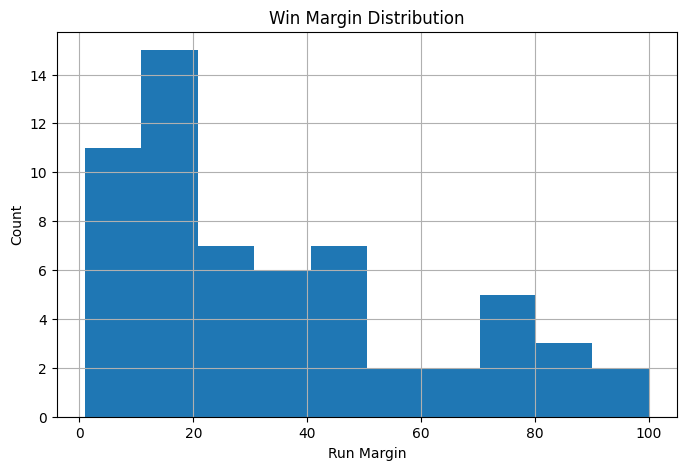

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(ipl["WinMargin"], bins=10)
plt.title("Win Margin Distribution")
plt.xlabel("Run Margin")
plt.ylabel("Count")
plt.grid()
plt.show()


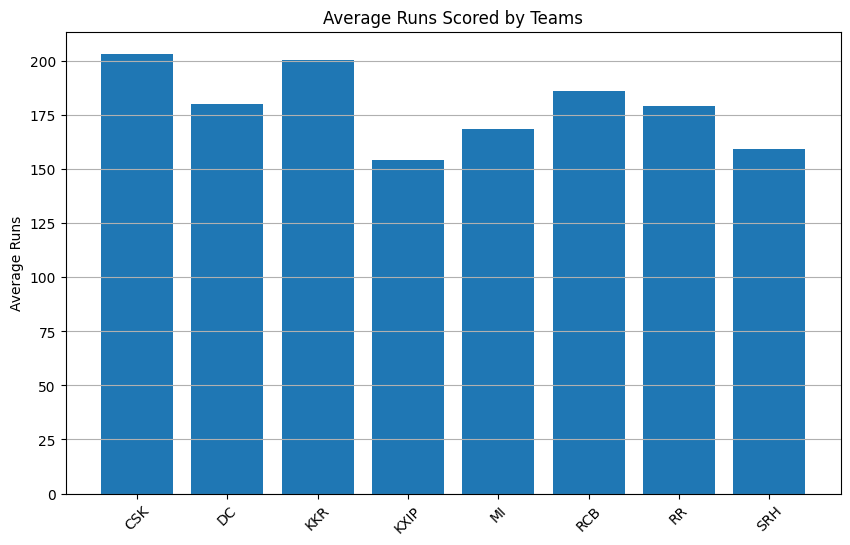

In [ ]:
team_avg = ipl.groupby("Team1")["Team1_Runs"].mean()#Team Average Runs

plt.figure(figsize=(10,6))
plt.bar(team_avg.index, team_avg.values)
plt.title("Average Runs Scored by Teams")
plt.xticks(rotation=45)
plt.ylabel("Average Runs")
plt.grid(axis='y')
plt.show()


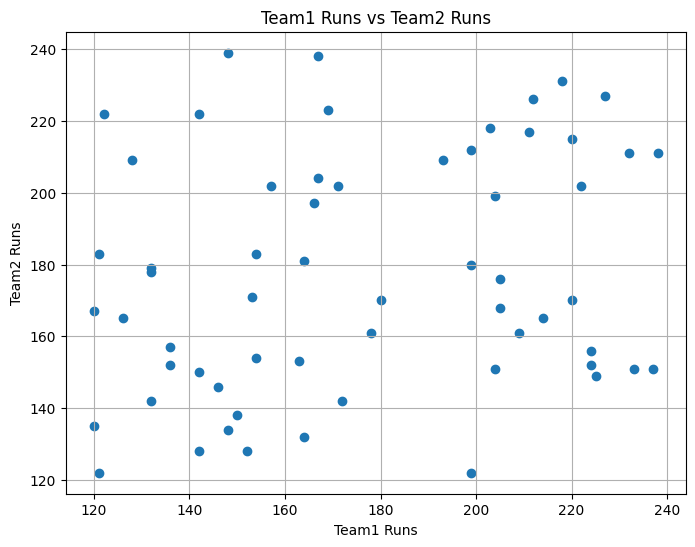

In [ ]:
plt.figure(figsize=(8,6))#t1 vs t2
plt.scatter(ipl["Team1_Runs"], ipl["Team2_Runs"])
plt.title("Team1 Runs vs Team2 Runs")
plt.xlabel("Team1 Runs")
plt.ylabel("Team2 Runs")
plt.grid()
plt.show()
